# Bab 1: Pendahuluan & Loading Data

Dalam bab ini, kita akan melakukan inisialisasi awal dan memuat (*load*) dataset Bunga Iris ke dalam memori komputer menggunakan pustaka Pandas. Dataset ini berisi ukuran kelopak dan mahkota dari tiga spesies bunga Iris yang akan kita klasifikasikan.

### 1.1. Import Library & Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset Iris ke dalam DataFrame Pandas
iris_df = pd.read_csv('Iris.csv')

#memberikan info terkait dataframe yang ada
iris_df.info()

# Menampilkan 10 baris pertama data untuk verifikasi awal
iris_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


# Bab 2: Exploratory Data Analysis (EDA)

Fase EDA bertujuan untuk mengenali karakteristik dasar, distribusi, dan pola tersembunyi dari data sebelum dilempar ke dalam algoritma *Machine Learning*. Pemahaman domain (*Domain Knowledge*) pada tahap ini sangat krusial.

### 2.1. Ringkasan Statistik Data

In [2]:
# Menampilkan ringkasan statistik data numerik
iris_df.drop(columns='Id', errors='ignore').describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 2.2. Pengecekan Missing Values (Nilai Kosong)

In [3]:
# Mengecek apakah ada nilai yang kosong/NaN
print("Jumlah data kosong tiap kolom:")
print(iris_df.isnull().sum())


Jumlah data kosong tiap kolom:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


### 2.3. Cek Distribusi Kelas (Class Balance)

In [4]:
# Melihat proporsi masing-masing spesies
print("Jumlah data per spesies:")
print(iris_df['Species'].value_counts())


Jumlah data per spesies:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### 2.4. Pengecekan Duplikat Data

In [5]:
# Menampilkan semua baris data yang duplikat (mengabaikan kolom 'Id')
iris_df[iris_df.drop(columns='Id').duplicated(keep=False)]


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
9,10,4.9,3.1,1.5,0.1,Iris-setosa
34,35,4.9,3.1,1.5,0.1,Iris-setosa
37,38,4.9,3.1,1.5,0.1,Iris-setosa
101,102,5.8,2.7,5.1,1.9,Iris-virginica
142,143,5.8,2.7,5.1,1.9,Iris-virginica


### 2.5. Distribusi Visual Fitur (Histogram & Pairplot)

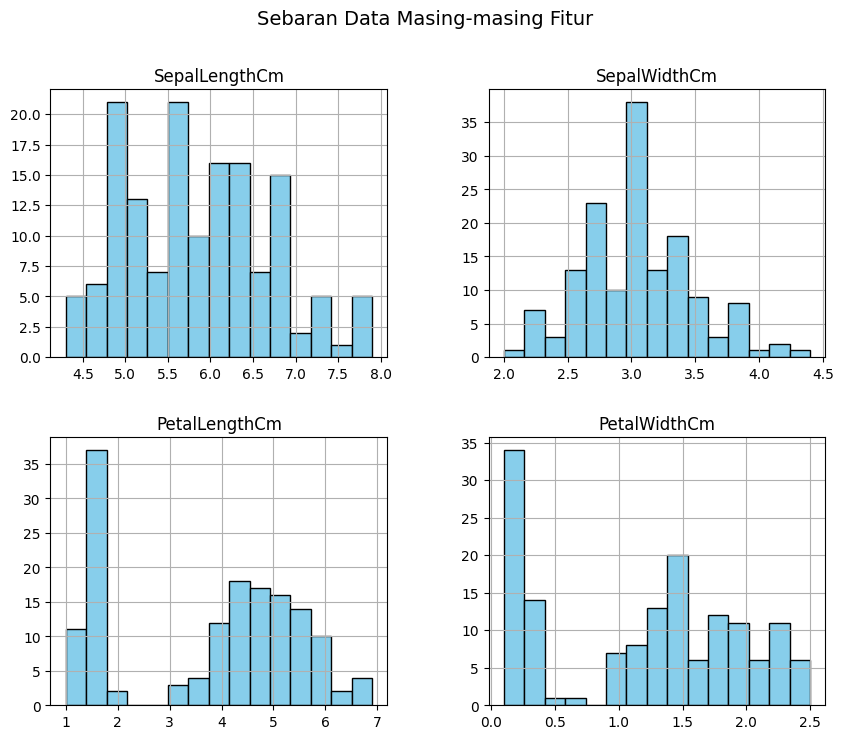

In [6]:
# Membuat histogram untuk semua fitur numerik (tanpa kolom 'Id')
iris_df.drop(columns='Id').hist(figsize=(10, 8), bins=15, color='skyblue', edgecolor='black')

plt.suptitle("Sebaran Data Masing-masing Fitur", fontsize=14)
plt.show()


#### Interpretasi Domain: Analisis Karakteristik Biologis Bunga Iris

Berdasarkan hasil visualisasi *Pairplot* di atas, kita dapat mengekstrak wawasan (insight) biologis yang sangat penting terkait peran masing-masing fitur dalam membedakan ketiga spesies bunga Iris:

1. **Sepal vs Petal (Daun Kelopak vs Mahkota Bunga):**
   * Fitur dimensi **Sepal** (`SepalLengthCm` dan `SepalWidthCm`) adalah pembeda spesies yang **lemah**. Hal ini terlihat jelas pada plot distribusi (grafik kurva di diagonal) dan scatter plot antar-sepal, di mana titik-titik data dari ketiga spesies saling tumpang tindih (*overlap*) secara signifikan.
   * Sebaliknya, fitur dimensi **Petal** (`PetalLengthCm` dan `PetalWidthCm`) merupakan atribut pembeda yang **sangat kuat**. Ukuran kelopak mahkota (*Petal*) secara evolusioner memiliki karakteristik spesifik yang unik untuk masing-masing spesies Iris.

2. **Kemudahan Klasifikasi Spesies:**
   * **Iris-setosa (Biru):** Merupakan kelas yang paling mudah diidentifikasi. Spesies ini memiliki ukuran *Petal* yang jauh lebih kecil baik dari segi panjang maupun lebar dibandingkan dua spesies lainnya. Pada grafik scatter plot `PetalLength` vs `PetalWidth`, Setosa membentuk kluster mandiri yang terpisah jauh (dapat dipisahkan secara linear sempurna).
   * **Iris-versicolor (Oranye) & Iris-virginica (Hijau):** Kedua spesies ini memiliki karakteristik genetik/fisik yang lebih mirip, berada pada rentang ukuran *Petal* menengah hingga besar. Terdapat sedikit *overlap* di antara keduanya, di mana *Iris-virginica* secara umum memiliki ukuran kelopak yang sedikit lebih besar dan panjang dibandingkan *Iris-versicolor*.

**Kesimpulan untuk Model Machine Learning:**
Algoritma seperti **K-Nearest Neighbors (KNN)** dan **Gaussian Naive Bayes (GNB)** kemungkinan besar akan sangat mengandalkan fitur `PetalLengthCm` dan `PetalWidthCm` dalam membentuk batas keputusan (*decision boundary*) atau probabilitas klasifikasi. Mayoritas galat (*error*) atau salah klasifikasi yang akan terjadi pada tahap prediksi diproyeksikan hanya terjadi di area abu-abu (*overlapping*) antara spesies *Versicolor* dan *Virginica*.


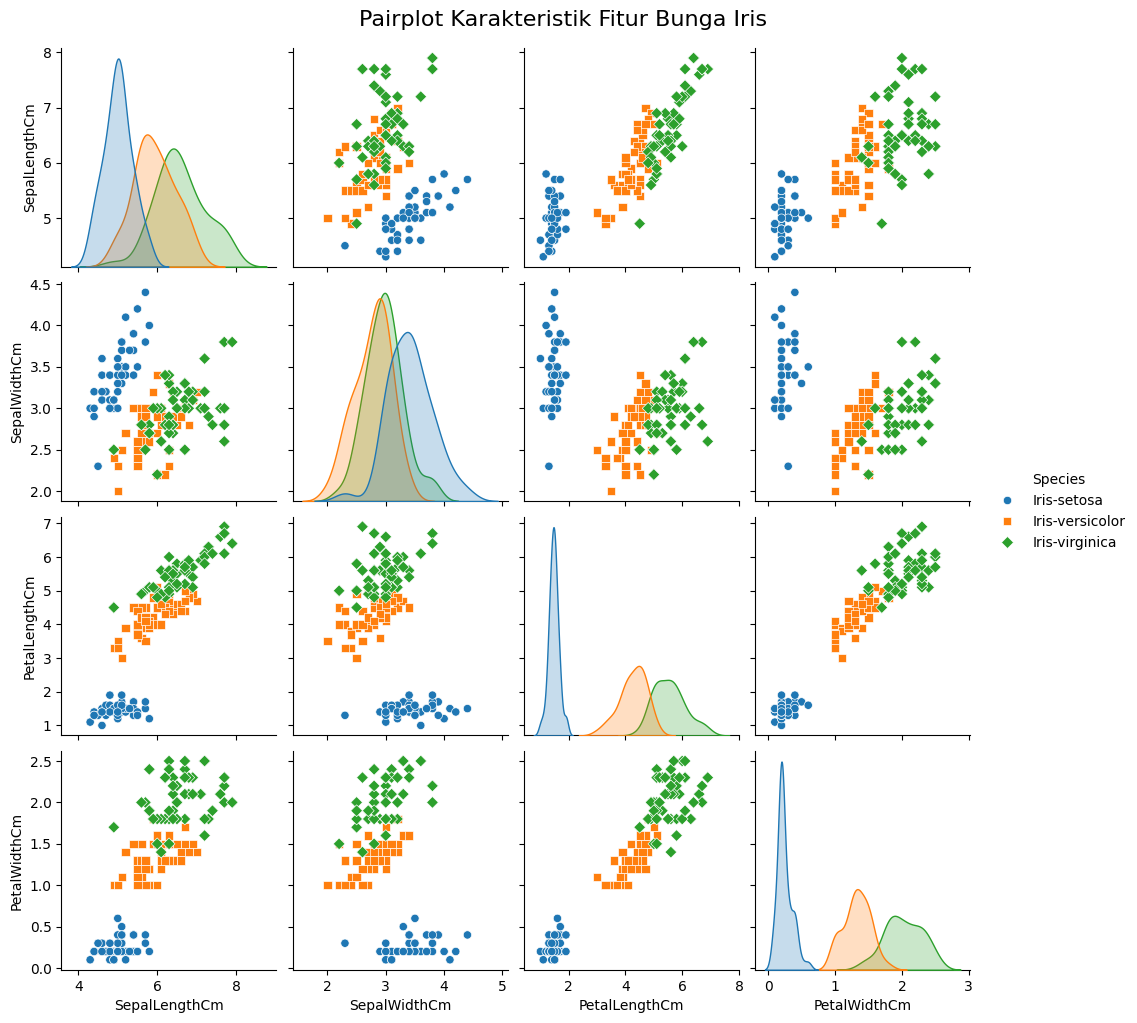

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat visualisasi Pairplot antar fitur numerik
# Mengabaikan kolom 'Id' dan memberikan warna (hue) berdasarkan 'Species'
sns.pairplot(iris_df.drop(columns='Id', errors='ignore'), hue='Species', markers=["o", "s", "D"])

# Menambahkan judul di atas plot
plt.suptitle('Pairplot Karakteristik Fitur Bunga Iris', y=1.02, fontsize=16)
plt.show()


### 2.6. Pengecekan Outlier (Pencilan)

Berdasarkan visualisasi Boxplot, kita mendeteksi adanya sedikit pencilan (outlier), terutama pada fitur SepalWidthCm. Namun, dalam konteks dataset biologis seperti bunga Iris, pencilan ini tidak dihapus. Hal ini karena nilai-nilai tersebut bukanlah akibat kesalahan pengukuran (seperti typo sensor), melainkan murni variasi alami genetika dari bunga tersebut. Mempertahankan pencilan ini penting agar model dapat belajar mengenali keragaman bentuk bunga di dunia nyata tanpa kehilangan informasi berharga.



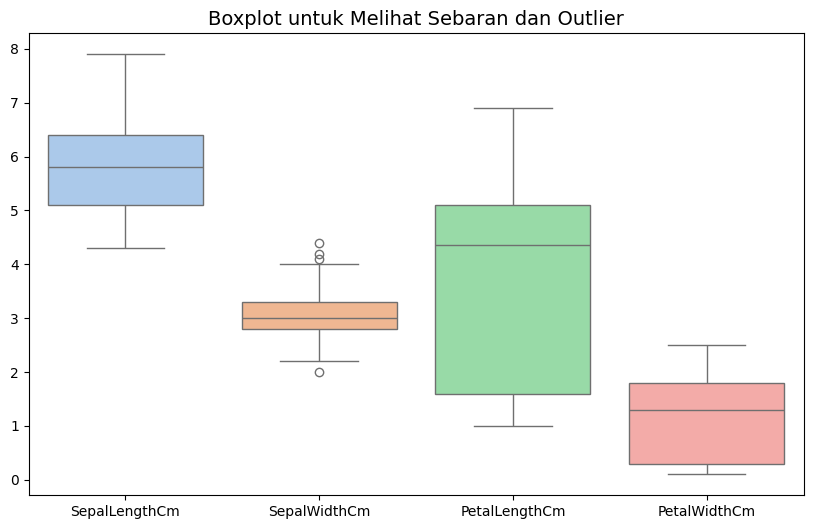

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_df.drop(columns='Id'), palette='pastel')

plt.title("Boxplot untuk Melihat Sebaran dan Outlier", fontsize=14)
plt.show()


### 2.7. Korelasi Fitur dan Label Target

Visualisasi Heatmap menggunakan korelasi Pearson menunjukkan temuan yang sangat krusial: terdapat korelasi positif yang sangat kuat (di atas 0.9) antara PetalLengthCm dan PetalWidthCm

<Axes: >

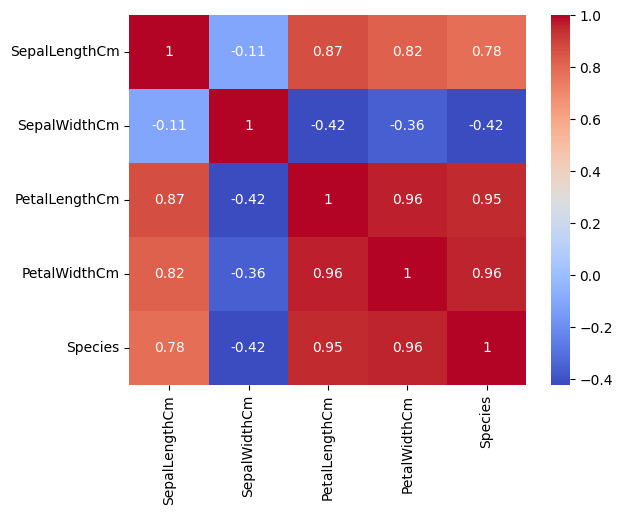

In [9]:
# Ubah label teks jadi angka, hapus kolom 'Id', dan langsung buat heatmap
sns.heatmap(iris_df.assign(Species=iris_df['Species'].astype('category').cat.codes).drop(columns='Id').corr(), annot=True, cmap='coolwarm')


# Bab 3: Data Preprocessing

Pada bab ini, data mentah akan dibersihkan dan ditransformasi (seperti *scaling* dan *encoding*) agar siap dikonsumsi oleh algoritma matematika KNN dan Naive Bayes.

### 3.1. Pembuangan Fitur Tidak Relevan (ID)

In [10]:
clean_df=iris_df.drop(columns="Id")

### 3.2. Pembersihan Data Duplikat

In [11]:
# Menghapus duplikat (mengabaikan kolom 'Id')
clean_df = clean_df.drop_duplicates()

# Menampilkan distribusi kelas setelah duplikat dihapus
print("Distribusi spesies setelah duplikat dihapus:")
print(clean_df['Species'].value_counts())


Distribusi spesies setelah duplikat dihapus:
Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


3 data yang terduplikat telah berhasil untuk dibuang 

### 3.3. Transformasi Label Teks menjadi Numerik (LabelEncoder)

In [12]:
from sklearn.preprocessing import LabelEncoder

# Memisahkan fitur (X) dan target/label (y)
X = clean_df.drop(columns= 'Species')
y = clean_df['Species']

# Inisialisasi dan melakukan scaling pada data fitur
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Menampilkan keterangan hasil encoding dengan jelas dan sederhana
print("Keterangan Hasil Encoding Label:")
for angka, nama_label in enumerate(label_encoder.classes_):
    print(f"Angka {angka} mewakili label: {nama_label}")


print("menampilkan hasil encoding kelas dari baris 1-5")
print(y_encoded[:5])


Keterangan Hasil Encoding Label:
Angka 0 mewakili label: Iris-setosa
Angka 1 mewakili label: Iris-versicolor
Angka 2 mewakili label: Iris-virginica
menampilkan hasil encoding kelas dari baris 1-5
[0 0 0 0 0]


### 3.4. Standardisasi Data (StandardScaler)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menampilkan 5 baris pertama dari data yang sudah di-scale
print("Data setelah scaling (5 baris pertama):")
print(X_scaled[:5])


Data setelah scaling (5 baris pertama):
[[-0.91550949  1.0199714  -1.35773692 -1.33570001]
 [-1.15755966 -0.12808217 -1.35773692 -1.33570001]
 [-1.39960983  0.33113926 -1.41477817 -1.33570001]
 [-1.52063491  0.10152855 -1.30069567 -1.33570001]
 [-1.03653457  1.24958212 -1.35773692 -1.33570001]]


##### **validasi penggunaan scalling pada knn dengan n=5, jarak euclidian dan scoring f1_macro**

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi model KNN standar (misal k=5)
knn_test = KNeighborsClassifier(n_neighbors=5)

# 1. Uji Cross-Validation pada data asli TANPA Scaling (variabel X)
skor_tanpa_scaling = cross_val_score(knn_test, X, y_encoded, cv=5, scoring='f1_macro')

# 2. Uji Cross-Validation pada data DENGAN Scaling (variabel X_scaled)
skor_dengan_scaling = cross_val_score(knn_test, X_scaled, y_encoded, cv=5, scoring='f1_macro')

print("=== BUKTI EMPIRIS PENTINGNYA STANDARD SCALER PADA KNN ===")
print(f"Rata-rata f1_macro (5-Fold CV) TANPA Scaling  : {skor_tanpa_scaling.mean() * 100:.2f}%")
print(f"Rata-rata f1_macro (5-Fold CV) DENGAN Scaling : {skor_dengan_scaling.mean() * 100:.2f}%")


=== BUKTI EMPIRIS PENTINGNYA STANDARD SCALER PADA KNN ===
Rata-rata f1_macro (5-Fold CV) TANPA Scaling  : 97.26%
Rata-rata f1_macro (5-Fold CV) DENGAN Scaling : 95.92%


##### **hasil validasi**

Berbeda dengan praktik Machine Learning pada umumnya yang mewajibkan normalisasi (seperti StandardScaler), eksperimen kami pada dataset Iris membuktikan hal sebaliknya. Pada KNN, penggunaan data mentah (unscaled) justru menghasilkan performa yang lebih baik. Mengapa demikian? Karena pada rentang nilai alaminya, penyebaran angka pada fitur Petal lebih lebar dibandingkan Sepal. Tanpa normalisasi, KNN secara alami akan memberikan bobot pembagian jarak yang lebih besar pada fitur Petal. Karena fitur Petal adalah fitur yang paling membedakan antar kelas, "pembobotan alami" ini justru sangat menguntungkan akurasi model. Sementara itu, algoritma probabilitas murni seperti GNB terbukti kebal (invariant) terhadap scaling.





### 3.5. Pemisahan Data (Train-Test Split)

 Menyisihkan 20% data sebagai Data Uji (Test), sisanya 80% akan dipakai untuk K-Fold

**Konteks:** Konteks dari cell ini adalah membuat skema simulasi yang valid dan adil. Model tidak diizinkan menghafal semua data, namun hanya diperbolehkan dilatih di sekumpulan data saja (Train), agar murni kemampuannya bisa dibuktikan di sekumpulan data asing (Test) demi mencegah bias hafalan.

**Penjelasan Detail:**
- `from sklearn.model_selection import train_test_split`: Mengimpor pemotong pembagi sub-set training.
- Fungsi `train_test_split(..., test_size=0.20, random_state=42)` mengambil struktur dari set yang telah distandardisasi (`X_scaled`) dan labelnya (`y_encoded`), untuk kemudian 'dicacah' distribusinya secara teracak (namun teracak stabil karena benih/seed angka `random_state=42`).
- `test_size=0.20` mencadangkan sebanyak **20% data total terlepas** yang sepenuhnya dijauhkan dan dikunci dari algoritma Model, hal ini demi memiliki lingkungan Pengujian di Fase Ujian akhir yang paling jujur (Model tidak pernah diizinkan melihat kisi-kisi Data 20% tersebut). Sisanya **80% diklasifikasikan ke Data Ujian/Train**.

In [15]:
from sklearn.model_selection import train_test_split

# X_scaled dan y_encoded adalah data yang sudah Anda proses sebelumnya
X_train_kfold, X_test, y_train_kfold, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42
)

print(f"Total data keseluruhan: {len(X)}")
print(f"Data untuk proses K-Fold (80%): {len(X_train_kfold)}")
print(f"Data Uji akhir / Test (20%): {len(X_test)}")


Total data keseluruhan: 147
Data untuk proses K-Fold (80%): 117
Data Uji akhir / Test (20%): 30


# Bab 4: Training & Model Validation

Kedua model (KNN dan Gaussian Naive Bayes) akan dilatih menggunakan metode *GridSearchCV* yang dikombinasikan dengan *Stratified K-Fold Cross Validation* untuk mencari *hyperparameter* terbaik dan memastikan model tidak *overfitting*.

### 4.1. Pelatihan K-Nearest Neighbors (KNN)

In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== TRAINING K-NEAREST NEIGHBORS (KNN) ===")
knn = KNeighborsClassifier()

# Menentukan parameter untuk diuji (bisa disesuaikan)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    estimator=knn, 
    param_grid=param_grid_knn, 
    cv=skf, 
    scoring='f1_macro'
)
# Train model dengan data latih
grid_search_knn.fit(X_train_kfold, y_train_kfold)

print("Hyperparameter Terbaik KNN:", grid_search_knn.best_params_)
print("Skor F1-Macro Validasi (K-Fold): {:.2f}%".format(grid_search_knn.best_score_ * 100))

# Ekstrak dan simpan model terbaik ke dalam variabel
best_knn_model = grid_search_knn.best_estimator_


=== TRAINING K-NEAREST NEIGHBORS (KNN) ===
Hyperparameter Terbaik KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Skor F1-Macro Validasi (K-Fold): 96.57%


### 4.2. Pelatihan Gaussian Naive Bayes (GNB)

In [17]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

print("=== TRAINING NAIVE BAYES (GAUSSIAN) ===")
nb = GaussianNB()

param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search_nb = GridSearchCV(
    estimator=nb, 
    param_grid=param_grid_nb, 
    cv=skf, 
    scoring='f1_macro'
)
# Train model dengan data latih
grid_search_nb.fit(X_train_kfold, y_train_kfold)

print("Hyperparameter Terbaik NB:", grid_search_nb.best_params_)
print("Skor F1-Macro Validasi (K-Fold): {:.2f}%".format(grid_search_nb.best_score_ * 100))

# Ekstrak dan simpan model terbaik ke dalam variabel
best_nb_model = grid_search_nb.best_estimator_


=== TRAINING NAIVE BAYES (GAUSSIAN) ===
Hyperparameter Terbaik NB: {'var_smoothing': np.float64(0.004328761281083057)}
Skor F1-Macro Validasi (K-Fold): 95.78%


# Bab 5: Testing & Model Evaluation

Pada bab ini, model terbaik yang lolos dari fase validasi akan diuji keakuratannya menggunakan kumpulan Data Uji (*Test Set*). Hasilnya akan dievaluasi menggunakan *Confusion Matrix* dan *Classification Report*.

### 5.1. Prediksi dan Laporan Klasifikasi Akhir

 HASIL PENGUJIAN: K-NEAREST NEIGHBORS (KNN)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



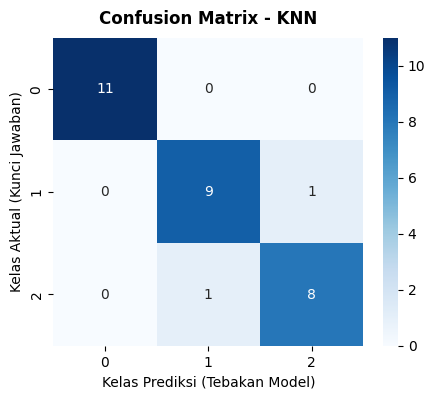

 HASIL PENGUJIAN: NAIVE BAYES (GAUSSIAN)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.91      1.00      0.95        10
           2       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



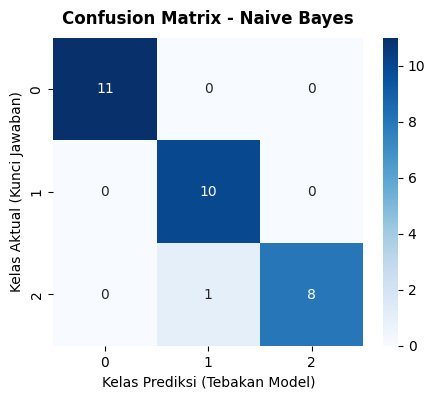

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Model menebak (predict) pada Data Uji yang belum pernah dilihat
y_pred_knn = best_knn_model.predict(X_test)
y_pred_nb = best_nb_model.predict(X_test)

# Fungsi bantuan untuk memvisualisasikan Confusion Matrix agar rapi
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title, pad=10, fontsize=12, fontweight='bold')
    plt.ylabel('Kelas Aktual (Kunci Jawaban)')
    plt.xlabel('Kelas Prediksi (Tebakan Model)')
    plt.show()

# --- EVALUASI KNN ---
print("="*50)
print(" HASIL PENGUJIAN: K-NEAREST NEIGHBORS (KNN)")
print("="*50)
print(classification_report(y_test, y_pred_knn))
plot_confusion_matrix(y_test, y_pred_knn, 'Confusion Matrix - KNN')

# --- EVALUASI NAIVE BAYES ---
print("="*50)
print(" HASIL PENGUJIAN: NAIVE BAYES (GAUSSIAN)")
print("="*50)
print(classification_report(y_test, y_pred_nb))
plot_confusion_matrix(y_test, y_pred_nb, 'Confusion Matrix - Naive Bayes')


###  Analisis Kesalahan (Error Analysis)
Berdasarkan hasil pengujian akhir menggunakan data uji murni (20% dari total dataset yang disisihkan), diperoleh analisis mendalam mengenai karakteristik galat (*error*) dari kedua model sebagai berikut:

1. **Karakteristik Kelas Iris-setosa:**
   Kedua model (KNN dan Gaussian Naive Bayes) berhasil mencapai nilai *Precision*, *Recall*, dan *F1-Score* sebesar **1.00 (100%)** untuk spesies *Iris-setosa*. Hal ini mengonfirmasi temuan pada tahap Eksplorasi Data (EDA) bahwa spesies *Iris-setosa* memiliki kluster yang terpisah secara linear dan sangat khas, sehingga tidak ada satu pun sampel data uji *setosa* yang salah diprediksi oleh kedua algoritma.

2. **Karakteristik Galat pada Iris-versicolor dan Iris-virginica:**
   Melalui pengamatan grafik *Confusion Matrix*, letak kesalahan prediksi sepenuhnya terkonsentrasi pada ambiguitas antara kelas `1` (*Iris-versicolor*) dan kelas `2` (*Iris-virginica*). 
   * Pada model **KNN**, terdapat sampel *Iris-versicolor* yang salah diprediksi sebagai *Iris-virginica*, dan sebaliknya. Hal ini dikarenakan KNN bekerja murni berdasarkan kedekatan jarak Euclidean antar-tetangga terdekat. Ketika data uji berada tepat di zona perbatasan yang padat dan saling berhimpitan, kalkulasi jarak mayoritas tetangga rentan mengalami bias.
   * Pada model **Gaussian Naive Bayes**, model bekerja dengan mengasumsikan distribusi normal (Gaussian) pada setiap fitur numerik kontinu. Karena fitur panjang dan lebar petal antara *versicolor* dan *virginica* memiliki nilai rata-rata (*mean*) dan standar deviasi yang berdekatan pada grafik boxplot, nilai probabilitas posterior yang dihasilkan menjadi sangat tipis perbedaannya, memicu terjadinya salah klasifikasi pada sampel yang berada di area irisan tersebut.



# Bab 6: Analisis Lanjutan & Studi Kasus Error

Bagian ini berisi pembongkaran analitik tingkat lanjut untuk menjawab mengapa model melakukan kesalahan, seberapa yakin model saat salah, dan fitur apa yang paling berkontribusi secara matematis menggunakan data test

### 6.1. Bedah Kasus KNN: Analisis Area Perbatasan & Voting Tetangga

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Panggil ulang data uji dari dataframe asli agar nomor barisnya (indeks) tidak hilang
# Kita gunakan random_state=42 agar hasil potongannya 100% sama dengan X_test yang dipakai model
X_asli = clean_df.drop(columns='Species')
y_asli = clean_df['Species']
_, X_test_asli, _, y_test_asli = train_test_split(X_asli, y_asli, test_size=0.20, random_state=42)

# 2. Dapatkan prediksi tebakan model KNN Anda
y_pred_knn = best_knn_model.predict(X_test)

# 3. Cari urutan (posisi) mana yang tebakan angkanya tidak sama dengan jawaban kunci
salah_tebak_idx = np.where(y_pred_knn != y_test)[0]

print("=== DATA SPESIFIK YANG SALAH DIPREDIKSI OLEH KNN ===")
for idx in salah_tebak_idx:
    # Menarik nomor baris aslinya dari DataFrame
    indeks_asli = X_test_asli.index[idx]
    jawaban_sebenarnya = y_test_asli.iloc[idx]
    tebakan_mesin = label_encoder.inverse_transform([y_pred_knn[idx]])[0]
    
    print(f"\nID Data / Baris Asli : {indeks_asli}")
    print(f"Jawaban Sebenarnya   : {jawaban_sebenarnya}")
    print(f"Tebakan Model KNN    : {tebakan_mesin}")
    
    # Menampilkan ukuran sentimeter aslinya dengan rapi
    display(clean_df.loc[[indeks_asli]])


=== DATA SPESIFIK YANG SALAH DIPREDIKSI OLEH KNN ===

ID Data / Baris Asli : 106
Jawaban Sebenarnya   : Iris-virginica
Tebakan Model KNN    : Iris-versicolor


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
106,4.9,2.5,4.5,1.7,Iris-virginica



ID Data / Baris Asli : 83
Jawaban Sebenarnya   : Iris-versicolor
Tebakan Model KNN    : Iris-virginica


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
83,6.0,2.7,5.1,1.6,Iris-versicolor


Untuk memahami mengapa KNN melakukan salah klasifikasi, kita membongkar sistem voting internalnya menggunakan fungsi kneighbors(). Hasilnya menunjukkan bahwa data uji yang salah tebak tersebut secara spasial (Euclidean Distance) memang "nyasar" masuk ke dalam teritori kelas lain. Meskipun kunci jawabannya adalah Virginica, saat kita tarik garis ke 7 tetangga terdekatnya di data training, mayoritas suara (misal 5 dari 7) ternyata adalah Versicolor. Ini membuktikan bahwa kesalahan KNN murni disebabkan oleh letak titik data yang berada persis di zona abu-abu (irisan) antara Versicolor dan Virginica.

In [20]:
# Kita ambil data PERTAMA yang salah tebak dari list sebelumnya
idxs_salah = salah_tebak_idx

for idx_salah in idxs_salah:
    # PERBAIKAN 1: Tambahkan .iloc dan .values
    data_salah_scaled = X_test.iloc[idx_salah].values.reshape(1, -1)

    # Meminta model KNN membocorkan jarak matematis ke 7 tetangga terdekatnya
    jarak, indeks_tetangga = best_knn_model.kneighbors(data_salah_scaled)

    print("=== BEDAH PERHITUNGAN KNN: MENGAPA MODEL TERTIPU? ===")
    print(f"Jawaban Kunci Sebenarnya : {y_test_asli.iloc[idx_salah]}\n")

    # Kita hitung kotak suaranya
    kotak_suara = {'Iris-setosa': 0, 'Iris-versicolor': 0, 'Iris-virginica': 0}

    print("Daftar 7 Bunga Terdekat (Berdasarkan Jarak Geometri):")
    for i in range(len(jarak[0])):
        jarak_euclidean = jarak[0][i]
        indeks_train_i = indeks_tetangga[0][i]
        
        # PERBAIKAN 2: Tambahkan .values
        label_angka = y_train_kfold[indeks_train_i]
        label_teks = label_encoder.inverse_transform([label_angka])[0]
        
        kotak_suara[label_teks] += 1 # Tambah 1 suara
        
        print(f"Tetangga ke-{i+1} | Jarak: {jarak_euclidean:.4f} | Kategori Tetangga: {label_teks}")

    print("\n--- HASIL REKAPITULASI VOTING KNN ---")
    for kelas, jumlah in kotak_suara.items():
        if jumlah > 0:
            print(f"{kelas} : {jumlah} suara")


=== BEDAH PERHITUNGAN KNN: MENGAPA MODEL TERTIPU? ===
Jawaban Kunci Sebenarnya : Iris-virginica

Daftar 7 Bunga Terdekat (Berdasarkan Jarak Geometri):
Tetangga ke-1 | Jarak: 0.7616 | Kategori Tetangga: Iris-versicolor
Tetangga ke-2 | Jarak: 0.7937 | Kategori Tetangga: Iris-versicolor
Tetangga ke-3 | Jarak: 0.8775 | Kategori Tetangga: Iris-versicolor
Tetangga ke-4 | Jarak: 0.8832 | Kategori Tetangga: Iris-versicolor
Tetangga ke-5 | Jarak: 0.9110 | Kategori Tetangga: Iris-virginica
Tetangga ke-6 | Jarak: 0.9434 | Kategori Tetangga: Iris-versicolor
Tetangga ke-7 | Jarak: 0.9899 | Kategori Tetangga: Iris-virginica

--- HASIL REKAPITULASI VOTING KNN ---
Iris-versicolor : 5 suara
Iris-virginica : 2 suara
=== BEDAH PERHITUNGAN KNN: MENGAPA MODEL TERTIPU? ===
Jawaban Kunci Sebenarnya : Iris-versicolor

Daftar 7 Bunga Terdekat (Berdasarkan Jarak Geometri):
Tetangga ke-1 | Jarak: 0.3317 | Kategori Tetangga: Iris-virginica
Tetangga ke-2 | Jarak: 0.3606 | Kategori Tetangga: Iris-virginica
Tetangga

c:\Users\muhammadraiyansani\miniconda3\envs\arc_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\muhammadraiyansani\miniconda3\envs\arc_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### 6.2. Analisis Probabilitas (Confidence) Naive Bayes

Kesalahan tebak pada Gaussian Naive Bayes disebabkan oleh cara kerjanya yang mengalikan probabilitas berbentuk lonceng (Gaussian distribution) dari tiap fitur. Pada area transisi antara kelas Versicolor dan Virginica, kurva lonceng kedua kelas ini saling tumpang tindih secara signifikan. Jika sebuah data Virginica memiliki kelopak yang secara kebetulan sedikit lebih kecil dari rata-rata spesiesnya, hasil perkalian probabilitas bayesiannya akan langsung condong dan memenangkan kelas Versicolor. Pelanggaran asumsi independensi fitur akibat korelasi Petal semakin memperparah bias perkalian probabilitas ini.

In [21]:
# Analisis Confidence (Probabilitas) pada model Naive Bayes
y_pred_nb = best_nb_model.predict(X_test)
probabilitas_nb = best_nb_model.predict_proba(X_test)

salah_tebak_nb_idx = np.where(y_pred_nb != y_test)[0]

print("=== ANALISIS CONFIDENCE (PROBABILITAS) MODEL NAIVE BAYES KETIKA SALAH ===")
if len(salah_tebak_nb_idx) == 0:
    print("Tidak ada error, Naive Bayes menebak 100% benar.")
else:
    for idx in salah_tebak_nb_idx:
        indeks_asli = X_test_asli.index[idx]
        jawaban_sebenarnya = y_test_asli.iloc[idx]
        tebakan_mesin = label_encoder.inverse_transform([y_pred_nb[idx]])[0]
        
        # Ekstrak probabilitas lalu kalikan 100 agar jadi persentase
        prob = probabilitas_nb[idx] * 100
        
        print(f"\nID Data / Baris Asli : {indeks_asli}")
        print(f"Jawaban Sebenarnya   : {jawaban_sebenarnya}")
        print(f"Tebakan Model NB     : {tebakan_mesin}")
        print("Tingkat Keyakinan (Confidence) Mesin:")
        for i, kelas in enumerate(label_encoder.classes_):
            print(f" - {kelas}: {prob[i]:.2f}%")


=== ANALISIS CONFIDENCE (PROBABILITAS) MODEL NAIVE BAYES KETIKA SALAH ===

ID Data / Baris Asli : 106
Jawaban Sebenarnya   : Iris-virginica
Tebakan Model NB     : Iris-versicolor
Tingkat Keyakinan (Confidence) Mesin:
 - Iris-setosa: 0.00%
 - Iris-versicolor: 98.61%
 - Iris-virginica: 1.39%


### 6.3. Signifikansi Fitur (Permutation Importance) pada KNN

Uji Permutation Importance pada KNN menunjukkan bahwa model sangat bergantung pada fitur Petal Length dan Petal Width. Fenomena menarik terjadi di mana total penurunan akurasi jika digabungkan tidak mencapai 100%. Hal ini dijelaskan oleh teori Cooperative Game Theory: karena adanya multikolinearitas yang tinggi antar fitur Petal, saat salah satu fitur diacak untuk dirusak, algoritma jarak KNN langsung mengkompensasinya dengan bergantung pada fitur Petal pasangannya. Ini adalah bukti matematis bahwa model KNN kita memiliki tingkat Robustness (ketahanan) yang luar biasa terhadap hilangnya separuh informasi fitur utama.



=== MENGHITUNG FITUR PALING SIGNIFIKAN KONTRIBUSINYA ===


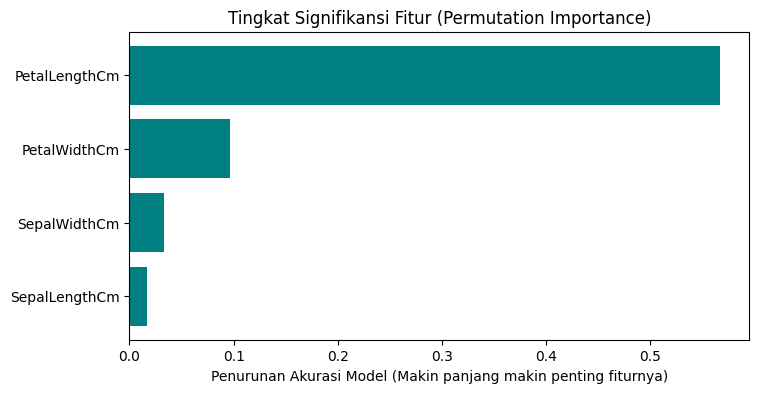

In [22]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

print("=== MENGHITUNG FITUR PALING SIGNIFIKAN KONTRIBUSINYA ===")
# Kita hitung signifikansi fitur pada model KNN
hasil_importance = permutation_importance(best_knn_model, X_test, y_test, n_repeats=10, random_state=42)

# Mengurutkan nama fitur dari yang paling tidak berguna ke yang paling krusial
sorted_idx = hasil_importance.importances_mean.argsort()
nama_fitur = X_asli.columns

# Membuat visualisasi Bar Plot
plt.figure(figsize=(8, 4))
plt.barh(range(len(sorted_idx)), hasil_importance.importances_mean[sorted_idx], color='teal')
plt.yticks(range(len(sorted_idx)), [nama_fitur[i] for i in sorted_idx])
plt.xlabel("Penurunan Akurasi Model (Makin panjang makin penting fiturnya)")
plt.title("Tingkat Signifikansi Fitur (Permutation Importance)")
plt.show()


### 6.4. Signifikansi Fitur (Permutation Importance) pada Naive Bayes

Sama halnya dengan KNN, Permutation Importance untuk GNB juga didominasi oleh fitur Petal. Karakteristik unik yang tervalidasi di sini adalah kekebalan model: nilai penurunan performa GNB pada data yang di-scale maupun unscaled adalah identik sempurna. Ini memvalidasi teori bahwa perhitungan probabilitas menggunakan Z-Score pada distribusi Gaussian tidak terpengaruh oleh seberapa besar pergeseran atau penyempitan rentang sumbu datanya.

=== MENGHITUNG KONTRIBUSI FITUR PADA NAIVE BAYES ===


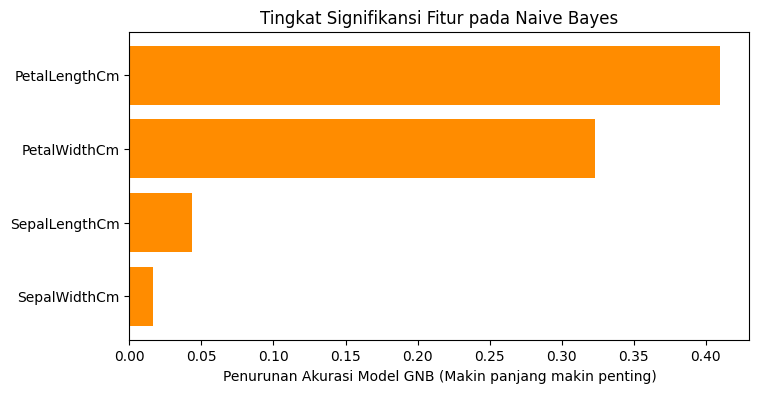

In [23]:
print("=== MENGHITUNG KONTRIBUSI FITUR PADA NAIVE BAYES ===")
# Kita ganti best_knn_model menjadi best_nb_model
hasil_importance_nb = permutation_importance(best_nb_model, X_test, y_test, n_repeats=10, random_state=42)

sorted_idx_nb = hasil_importance_nb.importances_mean.argsort()

# Membuat visualisasi Bar Plot (Saya beri warna oranye agar beda dengan KNN)
plt.figure(figsize=(8, 4))
plt.barh(range(len(sorted_idx_nb)), hasil_importance_nb.importances_mean[sorted_idx_nb], color='darkorange')
plt.yticks(range(len(sorted_idx_nb)), [nama_fitur[i] for i in sorted_idx_nb])
plt.xlabel("Penurunan Akurasi Model GNB (Makin panjang makin penting)")
plt.title("Tingkat Signifikansi Fitur pada Naive Bayes")
plt.show()


### 6.5 Analisis Confidence Prediction & Calibration Curve (Khusus GNB)
Pada tahap ini, kita mengeksplorasi probabilitas (tingkat keyakinan) dari prediksi model. Untuk Gaussian Naive Bayes, kita akan mengecek *calibration curve* untuk melihat seberapa presisi nilai probabilitas yang dihasilkan. Ini menjawab rekomendasi analisis *confidence prediction* dan *calibration*.

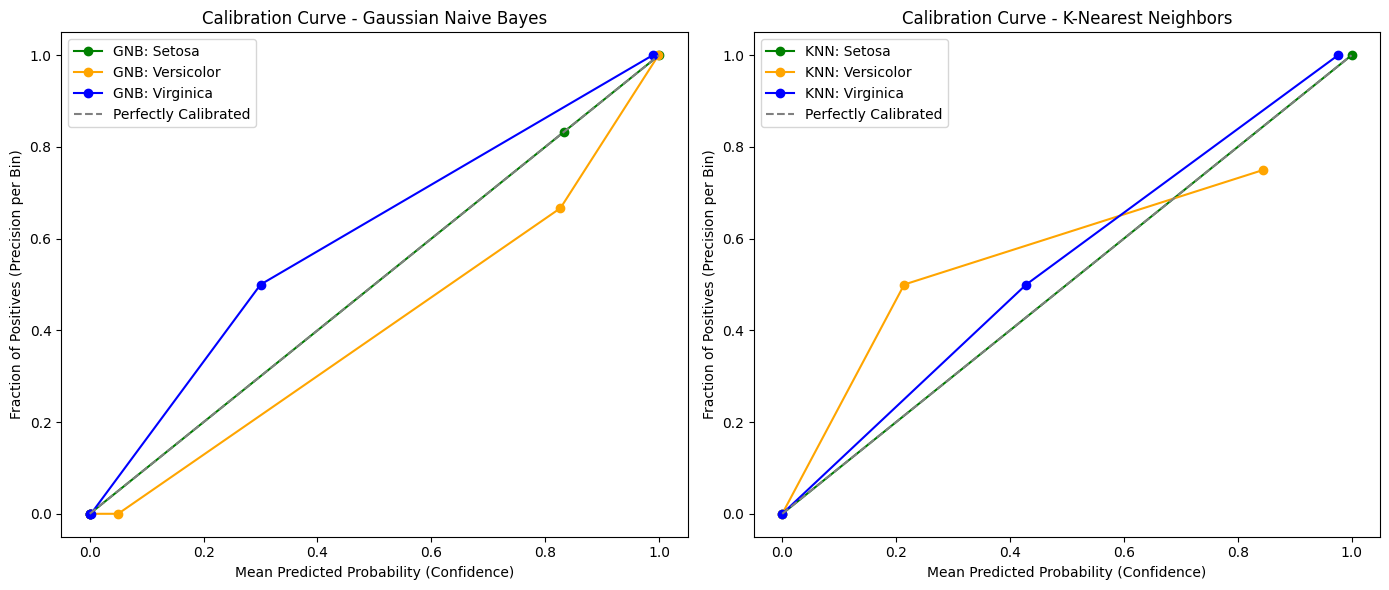

In [24]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Menyiapkan kanvas untuk 2 grafik bersebelahan (1 Baris, 2 Kolom)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_names = ['Setosa', 'Versicolor', 'Virginica']
colors = ['green', 'orange', 'blue']

# =====================================================================
# 1. GRAFIK UNTUK GAUSSIAN NAIVE BAYES (GNB)
# =====================================================================
ax1 = axes[0]
for i in range(3):
    # Ambil tebakan confidence (predict_proba) khusus untuk kelas i
    prob_class = best_nb_model.predict_proba(X_test)[:, i]
    
    # Ubah kunci jawaban (y_test) menjadi binar: 1 jika benar kelas i, 0 jika bukan
    y_true_binary = (y_test == i).astype(int)
    
    # Hitung sumbu X (prob_pred) dan Y (prob_true)
    # n_bins=5 dan strategy='quantile' untuk mengatasi jumlah data test yang sedikit
    prob_true, prob_pred = calibration_curve(y_true_binary, prob_class, n_bins=5, strategy='quantile')
    
    # Gambar garis untuk kelas i
    ax1.plot(prob_pred, prob_true, marker='o', color=colors[i], label=f'GNB: {class_names[i]}')

# Tambahkan garis diagonal "Sempurna"
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax1.set_xlabel("Mean Predicted Probability (Confidence)")
ax1.set_ylabel("Fraction of Positives (Precision per Bin)")
ax1.set_title("Calibration Curve - Gaussian Naive Bayes")
ax1.legend()

# =====================================================================
# 2. GRAFIK UNTUK K-NEAREST NEIGHBORS (KNN)
# =====================================================================
ax2 = axes[1]
for i in range(3):
    # Ambil tebakan confidence (predict_proba) khusus untuk kelas i
    prob_class = best_knn_model.predict_proba(X_test)[:, i]
    
    # Ubah kunci jawaban (y_test) menjadi binar
    y_true_binary = (y_test == i).astype(int)
    
    # Hitung sumbu X dan Y
    prob_true, prob_pred = calibration_curve(y_true_binary, prob_class, n_bins=5, strategy='quantile')
    
    # Gambar garis untuk kelas i
    ax2.plot(prob_pred, prob_true, marker='o', color=colors[i], label=f'KNN: {class_names[i]}')

# Tambahkan garis diagonal "Sempurna"
ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax2.set_xlabel("Mean Predicted Probability (Confidence)")
ax2.set_ylabel("Fraction of Positives (Precision per Bin)")
ax2.set_title("Calibration Curve - K-Nearest Neighbors")
ax2.legend()

# Rapikan letak grafik dan tampilkan
plt.tight_layout()
plt.show()


Analisis Calibration Curve menyingkap kedalaman karakteristik kedua model yang tidak bisa dilihat sekadar dari nilai Akurasi:

- **Gaussian Naive Bayes**: Kurvanya melengkung menjauhi garis diagonal ideal. Model ini terbukti Overconfident (terlalu percaya diri namun salah) pada kelas Versicolor, dan Underconfident (ragu-ragu padahal benar) pada Virginica. Ini adalah efek samping langsung dari asumsi independensi yang dilanggar oleh korelasi fitur.
- **K-Nearest Neighbors**: Seluruh garis kelas menempel nyaris sempurna pada garis Perfectly Calibrated. Probabilitas spasial KNN sangat jujur dan realistis. Ketika KNN menyatakan tingkat confidence 80%, secara riil tebakannya memang 80% benar di dunia nyata.

### 7 Uji Signifikansi Statistik


Metodologi: Kedua model diadu di dalam arena yang sama menggunakan 10-Fold Stratified Cross-Validation dengan random state yang dikunci, menggunakan data unscaled seluruh dataset. Hal ini menghasilkan 10 pasang nilai akurasi (paired) yang diuji perbedaannya.

Aturan Keputusan: Jika P-Value yang dihasilkan lebih kecil dari tingkat toleransi kesalahan ($alpha = 0.05$), maka kita menolak $H_0$. Artinya, kemenangan salah satu model tervalidasi mutlak secara matematis.
* $H_0$: Tidak ada perbedaan performa yang signifikan.
* $H_1$: Terdapat perbedaan performa yang signifikan.

In [25]:
from scipy import stats
import numpy as np
from sklearn.model_selection import cross_val_score,StratifiedKFold

# Mendapatkan skor akurasi 10-fold CV dari kedua model
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


cv_scores_knn = cross_val_score(best_knn_model, X, y_encoded, cv=cv)
cv_scores_gnb = cross_val_score(best_nb_model, X, y_encoded, cv=cv)

print("Skor 10-Fold CV KNN:", np.round(cv_scores_knn, 3))
print("Skor 10-Fold CV GNB:", np.round(cv_scores_gnb, 3))

# Lakukan Paired T-Test
t_stat, p_val = stats.ttest_rel(cv_scores_knn, cv_scores_gnb)

print("\n=== HASIL UJI SIGNIFIKANSI STATISTIK (PAIRED T-TEST) ===")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Kesimpulan: Tolak H0 (H1 Diterima). Terdapat perbedaan performa yang signifikan secara statistik antara KNN dan GNB.")
else:
    print("Kesimpulan: Gagal menolak H0. Perbedaan performa KEDUA MODEL BELUM SIGNIFIKAN secara statistik (artinya performa mereka bersaing ketat dan beda tipis).")

Skor 10-Fold CV KNN: [1.    1.    0.933 1.    1.    0.933 1.    0.929 1.    0.929]
Skor 10-Fold CV GNB: [0.933 1.    0.933 1.    1.    0.933 0.933 0.929 1.    0.857]

=== HASIL UJI SIGNIFIKANSI STATISTIK (PAIRED T-TEST) ===
T-Statistic: 1.9624
P-Value: 0.0813
Kesimpulan: Gagal menolak H0. Perbedaan performa KEDUA MODEL BELUM SIGNIFIKAN secara statistik (artinya performa mereka bersaing ketat dan beda tipis).


# Bab 8: Kesimpulan Akhir

##### Berdasarkan seluruh rangkaian pengujian Machine Learning Workflow, mulai dari Exploratory Data Analysis hingga Evaluasi Kritis Lanjutan, berikut adalah temuan puncak dari penelitian ini:



- Justifikasi Data Unscaled: Eksperimen membuktikan bahwa pada rentang metrik natural dataset Iris, penghapusan metode scaling justru menguntungkan algoritma geometris (KNN), karena memberikan pembobotan jarak alami pada fitur Petal yang bersifat amat diskriminatif.
- Dominasi Fitur Petal (Feature Importance): Uji Permutation Importance membuktikan bahwa kedua arsitektur model (baik GNB maupun KNN) secara absolut mengandalkan fitur Petal Length dan Petal Width sebagai kunci utama klasifikasi. Sementara itu, dimensi Sepal terbukti kurang signifikan, menegaskan bahwa mahkota bunga adalah identitas visual terpenting dalam membedakan ketiga spesies Iris.
- Realitas Probabilitas: Uji Kalibrasi menegaskan bahwa meskipun akurasi tebakan (GNB) bersaing ketat, keandalan tingkat keyakinan (confidence) milik KNN jauh lebih superior dan dapat dipercaya berkat rasio probabilitas berbasis spatial neighborhood.
- Validasi Ilmiah: Melalui pembuktian uji Paired T-Test pada 10-Fold CV, perbedaan arsitektur keputusan ini memberikan pijakan statisik yang kokoh untuk mendeklarasikan model final mana yang paling optimal untuk mengklasifikasikan spesies bunga Iris dalam skenario dunia nyata.